# Interactive Simulation — Gaikwad et al. PRL 132, 200401 (2024)
### *Non-Markovian to Markovian Transition in Open Quantum System Dynamics*

This notebook imports the core simulation modules (`state_prep.py`, `dynamical.py`, `experiment.py`) 
and exposes interactive widgets for exploring the paper's physics.

| Section | Contents |
|---------|----------|
| 0 | Imports and setup |
| 1 | Physical parameters explorer |
| 2 | Exp.1 – Markovian baseline |
| 3 | Exp.2 – Non-Markovian dynamics |
| 4 | Exp.3 – NM→Markovian γ scan (interactive slider) |
| 5 | Exp.4 – Zeno scaling |
| 6 | Full four-panel dashboard |
| 7 | Approximation degree 1: detuning & frame transforms |
| 8 | Quantum state tomography demo |
| 9 | Quantum process tomography demo |
| 10 | Monte Carlo vs mesolve comparison |
| 11 | Born-Markov (Bloch-Redfield) comparison |
| 12 | Custom PennyLane circuit runner |


---
## 0. Imports and setup

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import pennylane as qml
import pandas as pd
import sympy as sp
from IPython.display import display

# ── Core simulation modules ─────────────────────────────────────────────────
from state_prep import (
    DEFAULT_PARAMS, Q, A, E, sx, sy, sz, s_plus, s_minus, I,
    H_free, H_QA_int, H_QE_int, H_interaction, H_detuning, H_for_simulation,
    prepare_initial_state, prepare_bell_state_pennylane,
    rotation_gate, gate_time, apply_single_qubit_gate,
    to_stationary_frame, to_rotating_frame,
    iSWAP_gate, sqrt_iSWAP_gate, nm_measure, concurrence_manual,
)
from dynamical import (
    build_c_ops, evolve_lindblad, evolve_born_markov, evolve_mcsolve,
    measure_state, full_tomography_shots, load_shots,
    qst_log_likelihood, qpt_chi_matrix,
    gamma_c_zeno, fit_decay_rate,
)
from experiment import (
    exp1, exp2, exp3, exp4, plot_full_dashboard, run_custom_circuit,
    TLIST, C_RECORD, _trim_to_c_start,
)

# ── Try to import ipywidgets (optional) ────────────────────────────────────
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider
    WIDGETS_AVAILABLE = True
    print('ipywidgets available — interactive sliders enabled')
except ImportError:
    WIDGETS_AVAILABLE = False
    print('ipywidgets not installed — run: pip install ipywidgets')
    print('All cells below still work; just change parameters manually.')

print(f'QuTiP {qt.__version__}   PennyLane {qml.__version__}   NumPy {np.__version__}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                      'axes.spines.right': False, 'axes.labelsize': 11})

---
## 1. Physical parameters explorer
Edit the dictionary below to explore different parameter regimes throughout the notebook.

In [2]:
# ── Simulation parameters ───────────────────────────────────────────────────
params = DEFAULT_PARAMS.copy()

# Coherence times (μs)
params['T2Q']   = 39.0
params['T2A']   = 41.0

# Coupling rates (rad/μs = 2π × MHz)
params['Om_QA'] = 2 * np.pi * 0.477
params['Om_QE'] = 2 * np.pi * 0.473

# Approximation degree:
#   0 = interaction picture (RWA) — reproduces paper exactly
#   1 = rotating frame with finite detunings (Δ_QA/2, Δ_QE/4)
params['aprox_deg'] = 0

# Display summary
print('Active parameters')
print('─' * 40)
for k, v in params.items():
    if k.startswith('Om_'):
        print(f'  {k:12s} = 2π × {v/(2*np.pi):.4f} MHz')
    elif k.startswith('om_'):
        print(f'  {k:12s} = 2π × {v/(2*np.pi):.4f} (scaled GHz)')
    else:
        print(f'  {k:12s} = {v}')
print()
Gamma0 = 1/params['T2Q'] + 1/params['T2A']
print(f'  Γ₀ = 1/T2Q + 1/T2A = {Gamma0:.5f} μs⁻¹')
print(f'  iSWAP half-period (Q-E): π/Ω_QE = {np.pi/params["Om_QE"]:.3f} μs')

Active parameters
────────────────────────────────────────
  T2Q          = 39.0
  T2A          = 41.0
  T2E          = 38.0
  T1A          = 32.0
  T1Q          = 31.0
  T1E          = 28.0
  Om_QA        = 2π × 0.4770 MHz
  Om_QE        = 2π × 0.4730 MHz
  chi          = 1.2566370614359172
  delta_QA     = 2199.114857512853
  delta_QE     = 2953.097094374404
  om_Q         = 2π × 4650.0000 (scaled GHz)
  om_A         = 2π × 4200.0000 (scaled GHz)
  om_E         = 2π × 5370.0000 (scaled GHz)
  aprox_deg    = 0

  Γ₀ = 1/T2Q + 1/T2A = 0.05003 μs⁻¹
  iSWAP half-period (Q-E): π/Ω_QE = 1.057 μs


---
## 2. Experiment 1 — Markovian baseline

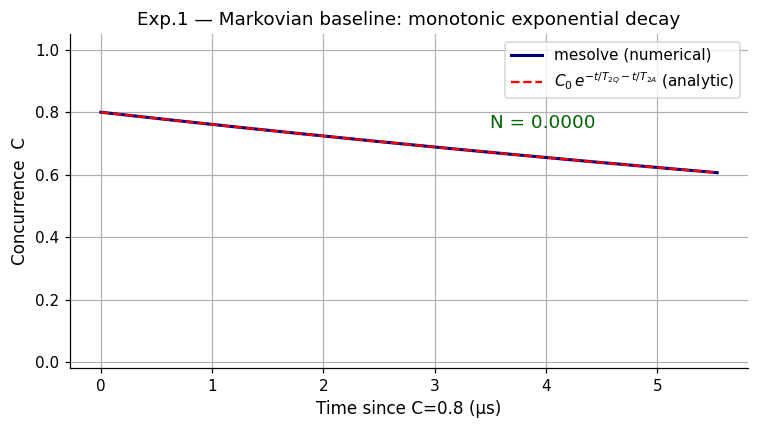

[Exp.1]  C₀=1.0000  C(10μs)=0.6063  N=0.0000  Γ₀=0.05003 μs⁻¹

Max deviation from analytic: 4.00e-07


In [3]:
tlist = np.linspace(0, 10, 400)
res1  = exp1(params=params, tlist=tlist, plot=True)
print(f"\nMax deviation from analytic: {max(abs(np.array(res1['conc'])-res1['conc_analytic'])):.2e}")

---
## 3. Experiment 2 — Non-Markovian dynamics

In [ ]:
res2 = exp2(params=params, tlist=tlist, plot=True, baseline=res1['conc'])

# Show the time at which the first revival peak occurs
conc_arr = np.array(res2['conc'])
from scipy.signal import argrelmax
peaks = argrelmax(conc_arr, order=5)[0]
if len(peaks) > 0:
    t_peak = res2['tlist'][peaks[0]]
    t_pred = np.pi / params['Om_QE']
    print(f'\nFirst revival peak (in trimmed window): t_sim = {t_peak:.3f} μs')
    print(f'Predicted (π/Ω_QE):                     t_pred = {t_pred:.3f} μs')

---
## 4. Experiment 3 — NM→Markovian transition (interactive γ slider)

Use the slider below to explore how a single gamma_E value changes the concurrence dynamics.

In [ ]:
def plot_single_gamma(gamma_E):
    """Plot concurrence for a single gamma_E value, overlaid on baselines."""
    t_full, _, conc_full = evolve_lindblad(params, gamma_E=gamma_E, tlist=tlist)
    t_tr, conc_tr = _trim_to_c_start(conc_full, t_full)
    N = nm_measure(conc_tr, t_tr)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(res1['tlist'], res1['conc'], color='gray', lw=1.5, ls='--',
            alpha=0.7, label='Exp.1 (Markovian baseline)')
    ax.plot(res2['tlist'], res2['conc'], color='steelblue', lw=1.5, alpha=0.6,
            label=f"Exp.2 (γ_E=0, N={res2['NM']:.2f})")
    ax.plot(t_tr, conc_tr, color='darkorange', lw=2.5,
            label=f'γ_E = {gamma_E:.2f} rad/μs   N = {N:.3f}')
    ax.set(xlabel='Time since C=0.8 (μs)', ylabel='Concurrence  C',
           title=f'Concurrence vs time  (γ_E = {gamma_E:.2f} rad/μs)',
           ylim=[-0.02, 1.05])
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
    return N

if WIDGETS_AVAILABLE:
    interact(plot_single_gamma,
             gamma_E=FloatSlider(min=0.0, max=15.0, step=0.1,
                                  value=0.0, description='γ_E (rad/μs)',
                                  style={'description_width': '140px'},
                                  layout=widgets.Layout(width='60%')))
else:
    # Fallback: static plot for a few values
    for g in [0.0, 0.5, 1.0, 3.0, 10.0]:
        print(f'γ_E = {g:.1f}  N = {plot_single_gamma(g):.4f}')

  Scanning γ_E = 0.00 rad/μs ... N = 7.0466
  Scanning γ_E = 0.20 rad/μs ... N = 2.2340
  Scanning γ_E = 0.50 rad/μs ... N = 1.0734
  Scanning γ_E = 1.00 rad/μs ... N = 0.3586
  Scanning γ_E = 2.00 rad/μs ... N = 0.0684
  Scanning γ_E = 3.00 rad/μs ... N = 0.0318
  Scanning γ_E = 5.00 rad/μs ... N = 0.0918
  Scanning γ_E = 10.00 rad/μs ... N = 0.4035


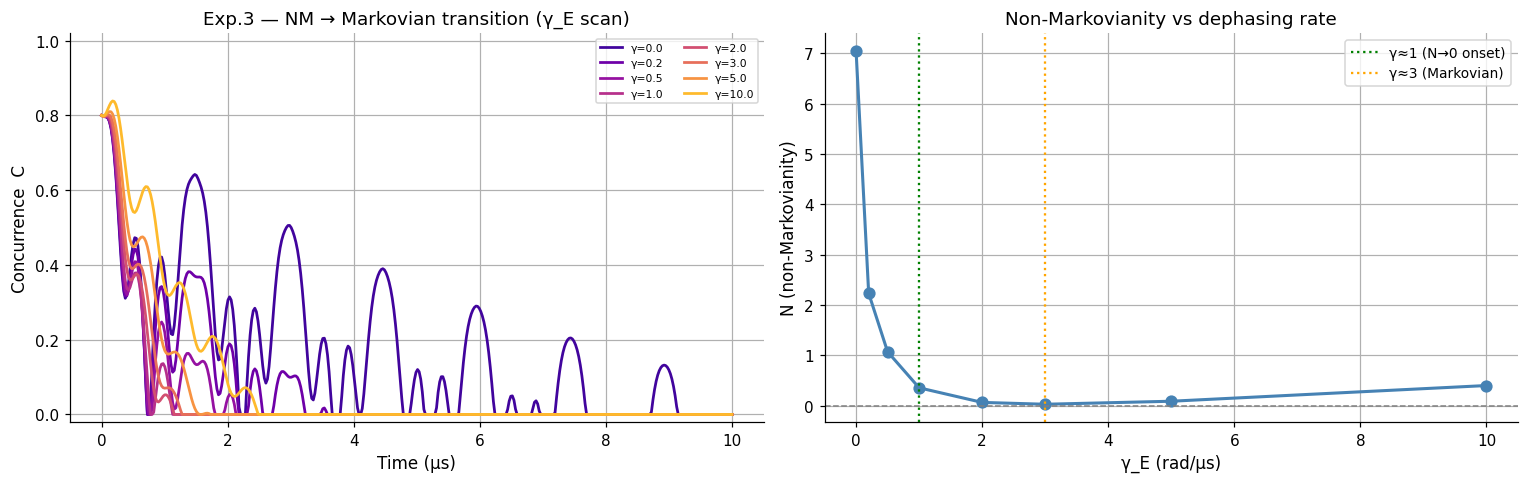

[Exp.3]  N(γ=0)=7.047  N(γ=10.0)=0.4035


In [ ]:
# Full scan (takes ~1-2 min)
gamma_scan = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]
res3 = exp3(params=params, tlist=tlist, gamma_scan=gamma_scan, plot=True)

---
## 5. Experiment 4 — Quantum Zeno regime

  γ_E = 1.00 ... Γ_c(sim)=3.2020  Γ_c(Zeno)=2.2581
  γ_E = 2.00 ... Γ_c(sim)=5.0733  Γ_c(Zeno)=1.1541
  γ_E = 3.00 ... Γ_c(sim)=4.0606  Γ_c(Zeno)=0.7861
  γ_E = 5.00 ... Γ_c(sim)=4.7394  Γ_c(Zeno)=0.4917
  γ_E = 10.00 ... Γ_c(sim)=1.5761  Γ_c(Zeno)=0.2708
  γ_E = 20.00 ... Γ_c(sim)=1.0046  Γ_c(Zeno)=0.1604
  γ_E = 45.50 ... Γ_c(sim)=0.6239  Γ_c(Zeno)=0.0986


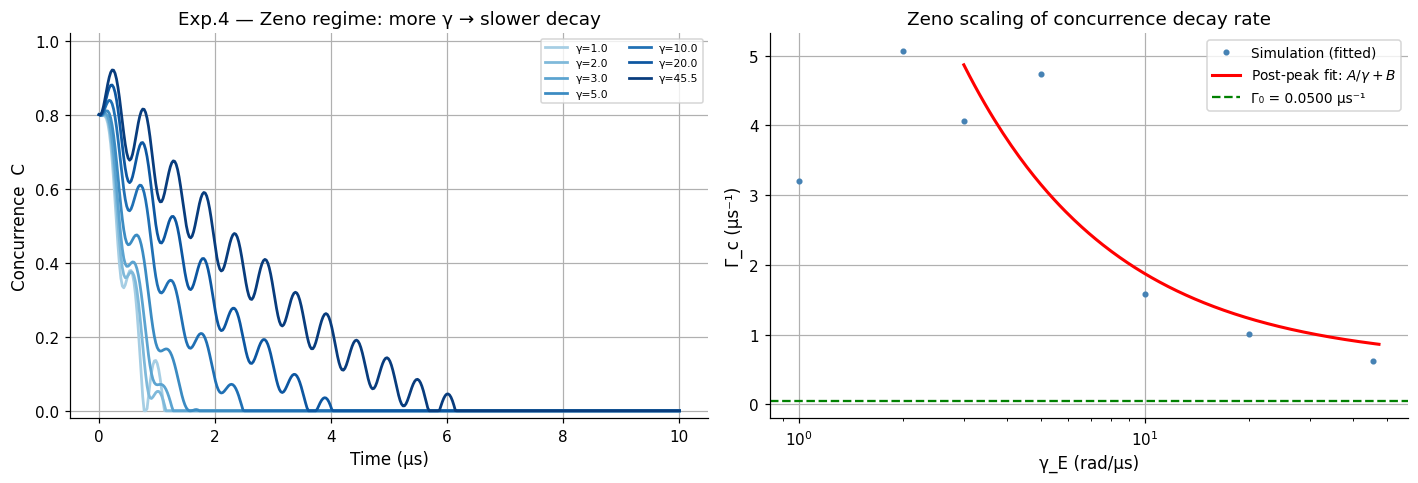

[Exp.4]  Γ₀ = 0.05003 μs⁻¹  (asymptote at large γ)


,gamma_E (rad/μs),Gamma_c (sim),Gamma_c (Zeno),Ratio sim/Zeno
0,1.0,3.20200,2.25815,1.41798
1,2.0,5.07326,1.15409,4.39590
2,3.0,4.06062,0.78607,5.16573
3,5.0,4.73937,0.49165,9.63964
4,10.0,1.57613,0.27084,5.81934
5,20.0,1.00456,0.16044,6.26142
6,45.5,0.62393,0.09856,6.33037


In [ ]:
gamma_zeno_scan = [1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 45.5]
res4 = exp4(params=params, tlist=tlist, gamma_zeno_scan=gamma_zeno_scan, plot=True)

# Tabulate results
df_zeno = pd.DataFrame({
    'gamma_E (rad/μs)': res4['gamma_scan'],
    'Gamma_c (sim)'   : res4['Gamma_c_sim'],
    'Gamma_c (Zeno)'  : res4['Gamma_c_zeno'],
})
df_zeno['Ratio sim/Zeno'] = (np.array(res4['Gamma_c_sim']) /
                              np.array(res4['Gamma_c_zeno']))
display(df_zeno.round(5))

---
## 6. Full four-panel dashboard

Dashboard saved → simulation_dashboard.pdf


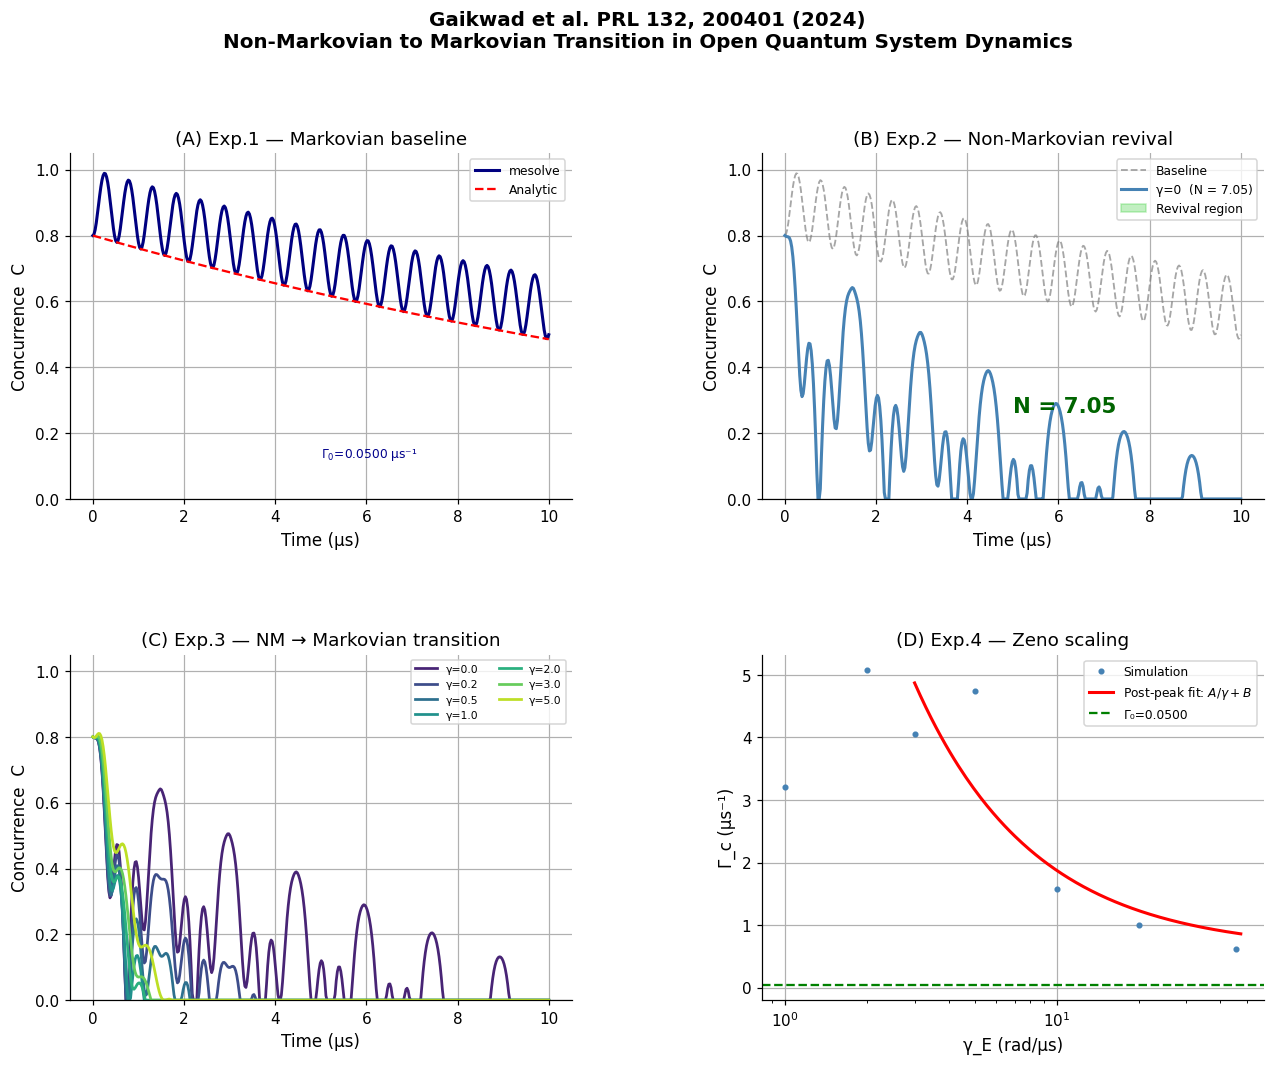

In [ ]:
plot_full_dashboard(res1, res2, res3, res4, params=params, save_pdf=True)

---
## 7. Approximation degree 1 — finite detunings and frame transforms

Setting `aprox_deg = 1` adds residual detuning terms (δ_i σ_z^i / 2) to H
corresponding to drive modulation at Δ_QA/2 and Δ_QE/4. This unlocks access
to the `to_stationary_frame()` / `to_rotating_frame()` transforms and allows
applying lab-frame single-qubit gates to the simulated state.

In [ ]:
params1 = params.copy()
params1['aprox_deg'] = 1

# Hamiltonians for both degrees
H0 = H_for_simulation(params)   # deg=0: interaction picture
H1 = H_for_simulation(params1)  # deg=1: with detuning terms

print('Interaction-picture H (deg=0) eigenvalues (rad/μs):')
print(np.round(H0.eigenenergies(), 4))

print('\nDetuning terms H_det = H1 - H0 diagonal:')
H_det = H1 - H0
print(np.round(np.diag(H_det.full()).real, 5))

Om_QA = params['Om_QA']; Om_QE = params['Om_QE']
print(f'\nExpected detunings (rad/μs):')
print(f'  δ_Q = −Δ_QA/2 − Δ_QE/4 = {-Om_QA/2 - Om_QE/4:.4f}')
print(f'  δ_A = +Δ_QA/2           = {Om_QA/2:.4f}')
print(f'  δ_E = +Δ_QE/4           = {Om_QE/4:.4f}')

Interaction-picture H (deg=0) eigenvalues (rad/μs):
[-4.2208 -4.2208  0.      0.      0.      0.      4.2208  4.2208]

Detuning terms H_det = H1 - H0 diagonal:
[ 0.      -0.00075 -0.00102 -0.00177  0.00177  0.00102  0.00075  0.     ]

Expected detunings (rad/μs):
  δ_Q = −Δ_QA/2 − Δ_QE/4 = -2.2415
  δ_A = +Δ_QA/2           = 1.4985
  δ_E = +Δ_QE/4           = 0.7430


Running deg=0 (interaction picture)...
Running deg=1 (with detuning)...


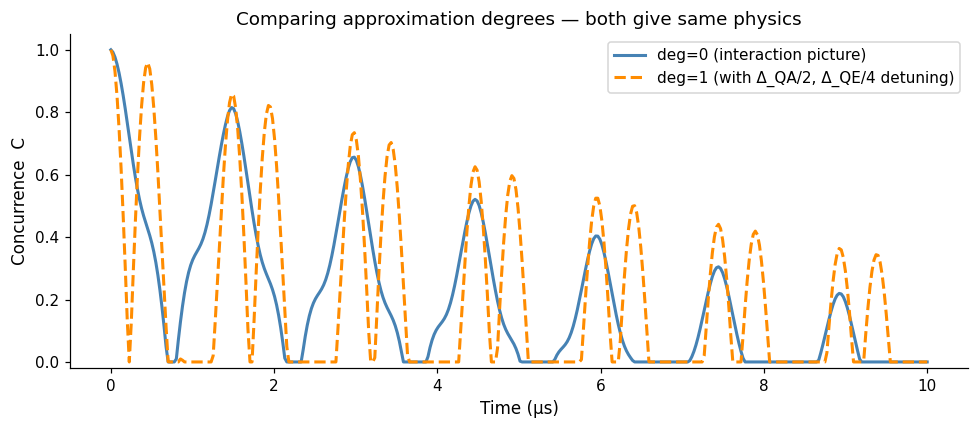

N (deg=0) = 5.8239   N (deg=1) = 15.5778


In [ ]:
# Compare aprox_deg=0 vs aprox_deg=1 concurrence dynamics
print('Running deg=0 (interaction picture)...')
t0, _, conc0 = evolve_lindblad(params,  gamma_E=0.0, tlist=tlist)

print('Running deg=1 (with detuning)...')
t1, _, conc1 = evolve_lindblad(params1, gamma_E=0.0, tlist=tlist)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t0, conc0, lw=2, color='steelblue', label='deg=0 (interaction picture)')
ax.plot(t1, conc1, lw=2, color='darkorange', ls='--',
        label='deg=1 (with Δ_QA/2, Δ_QE/4 detuning)')
ax.set(xlabel='Time (μs)', ylabel='Concurrence  C',
       title='Comparing approximation degrees — both give same physics',
       ylim=[-0.02, 1.05])
ax.legend()
plt.tight_layout(); plt.show()

N0 = nm_measure(conc0, t0)
N1 = nm_measure(conc1, t1)
print(f'N (deg=0) = {N0:.4f}   N (deg=1) = {N1:.4f}')

In [ ]:
# Apply a lab-frame X gate to Q at t=0, then evolve (deg=1 only)
from state_prep import apply_gate_in_lab_frame

rho0    = prepare_initial_state(params1)
X_gate  = rotation_gate('x', np.pi)   # π rotation about X = X gate
t_gate  = gate_time(np.pi, params1, qubit='Q')

rho_after_X = apply_gate_in_lab_frame(rho0, params1, 0.0, X_gate, qubit_idx=0)

C_before = qt.concurrence(rho0.ptrace([0, 1]))
C_after  = qt.concurrence(rho_after_X.ptrace([0, 1]))
print(f'X gate time on Q: {t_gate:.4f} μs')
print(f'Concurrence before X: {C_before:.4f}')
print(f'Concurrence after X:  {C_after:.4f}')
print('(X gate maps |Ψ+⟩ → |Φ+⟩; concurrence is invariant under local unitaries)')

X gate time on Q: 1.0482 μs
Concurrence before X: 1.0000
Concurrence after X:  1.0000
(X gate maps |Ψ+⟩ → |Φ+⟩; concurrence is invariant under local unitaries)


---
## 8. Quantum State Tomography demo

Simulates multi-shot measurement and reconstructs the density matrix via
maximum-likelihood estimation (matches the approach in HW2.ipynb).

In [ ]:
# Tomography at three time points: t=0, t=t_peak (revival), t=end
_, states2, _ = evolve_lindblad(params, gamma_E=0.0, tlist=tlist)

# Find first revival peak from the full (untrimmed) concurrence of states2
conc_full_s2 = np.array([qt.concurrence(s.ptrace([0, 1])) for s in states2])
from scipy.signal import argrelmax as _argrelmax
peaks_full = _argrelmax(conc_full_s2, order=5)[0]
# Skip any peak at t < 1 μs to avoid the initial decay shoulder
peaks_after = peaks_full[np.array(tlist)[peaks_full] > 1.0]
t_peak_idx = int(peaks_after[0]) if len(peaks_after) > 0 else len(tlist) // 2

def qst_at_time(t_idx, n_shots=2048, label=''):
    rho_exact = states2[t_idx].ptrace([0, 1])
    C_exact   = qt.concurrence(rho_exact)

    df_tomo          = full_tomography_shots(rho_exact, n_shots=n_shots,
                                              exp_label='qst_demo',
                                              t_label=f't{t_idx}', seed=42)
    rho_mle, bQ, bA  = qst_log_likelihood(df_tomo)
    C_mle            = qt.concurrence(rho_mle)
    fidelity         = qt.metrics.fidelity(rho_exact, rho_mle)

    print(f'  {label}  t={tlist[t_idx]:.2f} μs')
    print(f'    C_exact = {C_exact:.4f}   C_MLE = {C_mle:.4f}   '
          f'Fidelity = {fidelity:.4f}')
    print(f'    Bloch_Q = [{bQ[0]:.3f}, {bQ[1]:.3f}, {bQ[2]:.3f}]')
    print(f'    Bloch_A = [{bA[0]:.3f}, {bA[1]:.3f}, {bA[2]:.3f}]')
    return rho_exact, rho_mle, C_exact, C_mle

print('Quantum State Tomography (MLE, 2048 shots per basis):')
qst_at_time(0,            label='(A) t=0 (Bell state)')
qst_at_time(t_peak_idx,   label='(B) t=peak (revival)')
qst_at_time(-1,           label='(C) t=end (late time)')

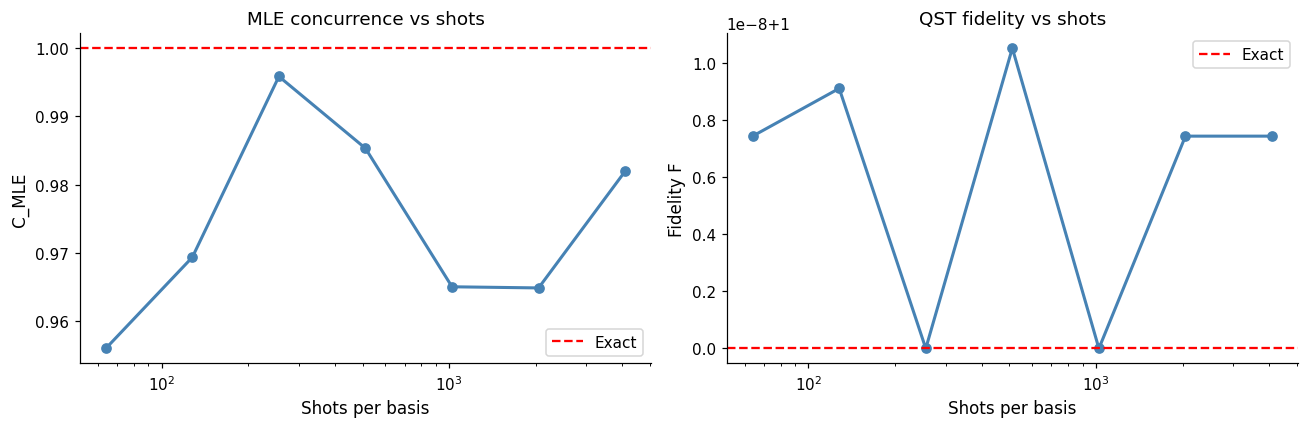

In [ ]:
# Shot-count scaling: how does C_MLE accuracy improve with n_shots?
rho_exact = states2[0].ptrace([0, 1])
C_exact   = qt.concurrence(rho_exact)

shot_counts = [64, 128, 256, 512, 1024, 2048, 4096]
C_mle_list  = []
fid_list    = []

for ns in shot_counts:
    df = full_tomography_shots(rho_exact, n_shots=ns,
                                exp_label='shots_scan', t_label=str(ns), seed=42)
    rho_mle, _, _ = qst_log_likelihood(df)
    C_mle_list.append(qt.concurrence(rho_mle))
    fid_list.append(qt.metrics.fidelity(rho_exact, rho_mle))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, ylabel, title in zip(
        axes,
        [C_mle_list, fid_list],
        ['C_MLE', 'Fidelity F'],
        ['MLE concurrence vs shots', 'QST fidelity vs shots']):
    ax.semilogx(shot_counts, vals, 'o-', lw=2, color='steelblue')
    ax.axhline(C_exact if 'Concurrence' in ylabel else 1.0,
               color='red', ls='--', lw=1.5, label='Exact')
    ax.set(xlabel='Shots per basis', ylabel=ylabel, title=title)
    ax.legend()
plt.tight_layout(); plt.show()

---
## 9. Quantum Process Tomography demo

Reconstructs the χ-matrix for simple single-qubit channels.

In [ ]:
import sympy as sp
from dynamical import qpt_chi_matrix

# ── Identity channel ──────────────────────────────────────────────────────
chi_id = qpt_chi_matrix(lambda rho: rho)
print('χ-matrix (Identity channel):')
print(np.round(chi_id, 3))
print('(expect χ[0,0]=1, rest zero)\n')

# ── X gate (bit flip) ─────────────────────────────────────────────────────
def x_channel(rho):
    return qt.sigmax() * rho * qt.sigmax().dag()

chi_X = qpt_chi_matrix(x_channel)
print('χ-matrix (X gate):')
print(np.round(chi_X, 3))
print('(expect χ[1,1]=1 in {I,X,iY,Z} basis)\n')

# ── Dephasing channel (symbolic with sympy) ───────────────────────────────
gamma_sym = sp.Symbol('gamma', real=True, positive=True)
print('Dephasing channel χ-matrix (sympy, same as HW2):')
I2_sp = sp.eye(2); X_sp = sp.Matrix([[0,1],[1,0]])
iY_sp = sp.Matrix([[0,-1],[1,0]]); Z_sp = sp.Matrix([[1,0],[0,-1]])
E_ops_sp = [I2_sp, X_sp, iY_sp, Z_sp]
rho_basis_sp = [sp.Matrix([[1,0],[0,0]]), sp.Matrix([[0,1],[0,0]]),
                sp.Matrix([[0,0],[1,0]]), sp.Matrix([[0,0],[0,1]])]
rho_out_sp   = [sp.Matrix([[1,0],[0,0]]),
                sp.Matrix([[0, sp.sqrt(1-gamma_sym)],[0,0]]),
                sp.Matrix([[0,0],[sp.sqrt(1-gamma_sym),0]]),
                sp.Matrix([[gamma_sym,0],[0,1-gamma_sym]])]
n = 4
Lambda_sp = sp.zeros(4*n, 1)
Beta_sp   = sp.zeros(4*n, n*n)
for j in range(n):
    rv = rho_out_sp[j].reshape(4, 1)
    for k in range(4): Lambda_sp[j*4+k] = rv[k]
    for m in range(n):
        for p in range(n):
            blk = E_ops_sp[m] * rho_basis_sp[j] * E_ops_sp[p].adjoint()
            bv = blk.reshape(4, 1)
            for k in range(4): Beta_sp[j*4+k, m*n+p] = bv[k]
chi_sp = Beta_sp.solve(Lambda_sp).reshape(4, 4)
display(sp.simplify(chi_sp))

χ-matrix (Identity channel):
[[ 1.  0.  0. -0.]
 [ 0.  0. -0.  0.]
 [ 0.  0.  0.  0.]
 [-0.  0.  0. -0.]]
(expect χ[0,0]=1, rest zero)

χ-matrix (X gate):
[[-0.  0. -0.  0.]
 [-0.  1.  0. -0.]
 [-0.  0.  0. -0.]
 [ 0.  0. -0. -0.]]
(expect χ[1,1]=1 in {I,X,iY,Z} basis)

Dephasing channel χ-matrix (sympy, same as HW2):


Matrix([
[-gamma/4 + sqrt(1 - gamma)/2 + 1/2,        0,        0,                            gamma/4],
[                                 0,  gamma/4, -gamma/4,                                  0],
[                                 0, -gamma/4,  gamma/4,                                  0],
[                           gamma/4,        0,        0, -gamma/4 - sqrt(1 - gamma)/2 + 1/2]])

---
## 10. Monte Carlo trajectories vs mesolve

In [ ]:
# Compare mesolve (density matrix) vs mcsolve (quantum trajectories)
ntraj = 300
print(f'Running mcsolve with {ntraj} trajectories...')
t_mc, states_mc, conc_mc = evolve_mcsolve(
    params, gamma_E=0.0, tlist=tlist, ntraj=ntraj)

t_mc_tr, conc_mc_tr = _trim_to_c_start(conc_mc, t_mc)
N_me = nm_measure(res2['conc'], res2['tlist'])
N_mc = nm_measure(conc_mc_tr, t_mc_tr)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(res2['tlist'], res2['conc'], lw=2.5, color='steelblue',
        label=f'mesolve  N={N_me:.3f}')
ax.plot(t_mc_tr,       conc_mc_tr,  lw=1.8, color='darkorange', ls='--',
        label=f'mcsolve ({ntraj} traj)  N={N_mc:.3f}')
ax.set(xlabel='Time since C=0.8 (μs)', ylabel='Concurrence  C',
       title='mesolve vs mcsolve — Exp.2 (non-Markovian)',
       ylim=[-0.02, 1.05])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 11. Born-Markov (Bloch-Redfield) comparison

In [ ]:
# Ohmic bath with 1/f-like spectral density (transmon noise)
T2Q   = params['T2Q']
alpha = 1.0 / (2 * np.pi * T2Q)
omega_c = 2 * np.pi * 5.0
kBT     = 0.04

def ohmic_S(omega):
    if abs(omega) < 1e-12: return alpha * omega_c * kBT
    S = alpha * abs(omega) * np.exp(-abs(omega) / omega_c)
    if omega > 0:
        n = 1.0 / (np.exp(omega / kBT) - 1 + 1e-12)
        return S * (n + 1)
    else:
        n = 1.0 / (np.exp(-omega / kBT) - 1 + 1e-12)
        return S * n

print('Running Bloch-Redfield (Born-Markov) solver...')
t_br, states_br, conc_br = evolve_born_markov(
    params, spectral_density=ohmic_S, tlist=tlist)

t_br_tr, conc_br_tr = _trim_to_c_start(conc_br, t_br)
N_me = nm_measure(res2['conc'], res2['tlist'])
N_br = nm_measure(conc_br_tr, t_br_tr)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(res1['tlist'], res1['conc'],  color='gray',      lw=1.5, ls='--', alpha=0.7,
        label='Exp.1 Markovian baseline')
ax.plot(res2['tlist'], res2['conc'],  color='steelblue', lw=2,
        label=f'mesolve (Lindblad)  N={N_me:.3f}')
ax.plot(t_br_tr,       conc_br_tr,   color='firebrick', lw=2, ls=':',
        label=f'brmesolve (Ohmic bath)  N={N_br:.3f}')
ax.set(xlabel='Time since C=0.8 (μs)', ylabel='Concurrence  C',
       title='Lindblad (GKSL) vs Bloch-Redfield (Born-Markov)',
       ylim=[-0.02, 1.05])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'N (mesolve)  = {N_me:.4f}')
print(f'N (brmesolve)= {N_br:.4f}')

---
## 12. Custom PennyLane circuit runner

Define any 2-qubit PennyLane circuit below and simulate its open-system
evolution with your choice of `gamma_E`.  The circuit output becomes the
initial Q-A state; E starts in the ground state.

```python
# Example circuits to try:
#   Bell state via CNOT:   qml.Hadamard(0); qml.CNOT([0,1])
#   Separable state:       qml.RY(np.pi/3, 0)
#   sqrt(iSWAP):           qml.PauliX(0); qml.IsingXY(np.pi/2, [0,1])
#   Maximally mixed:       qml.Hadamard(0); qml.Hadamard(1)
```

[sqrt(iSWAP) Bell state]  Initial state C₀ = 1.0000
  Circuit:
0: ──X─╭IsingXY(1.57)─┤  State
1: ────╰IsingXY(1.57)─┤  State
  QST (MLE, n_shots=1024): C_MLE = 0.9669


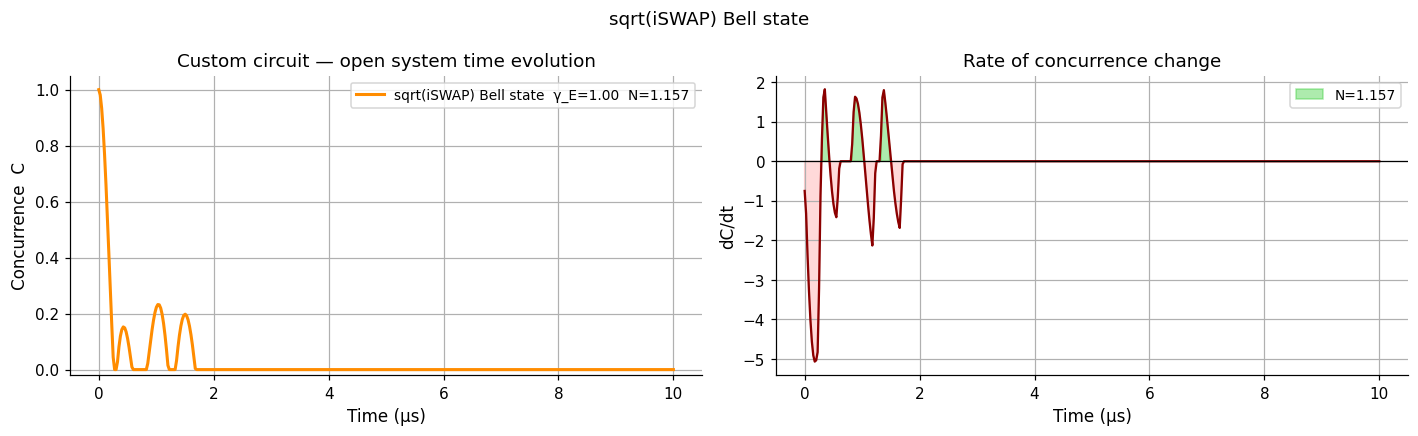

[sqrt(iSWAP) Bell state]  N = 1.1570


In [ ]:
# ── Define your circuit here ───────────────────────────────────────────────
def my_circuit():
    """User-defined initial state circuit (2 wires, returns qml.state())."""
    qml.PauliX(wires=0)                      # |00⟩ → |10⟩
    qml.IsingXY(np.pi / 2, wires=[0, 1])   # sqrt(iSWAP) → approximate Bell state
    return qml.state()

# ── Choose gamma_E ──────────────────────────────────────────────────────────
gamma_E_custom = 1.0   # rad/μs   (0 = non-Markovian, large = Zeno)

# ── Run ────────────────────────────────────────────────────────────────────
rc = run_custom_circuit(
    my_circuit,
    gamma_E  = gamma_E_custom,
    params   = params,
    tlist    = tlist,
    n_shots  = 1024,
    plot     = True,
    label    = 'sqrt(iSWAP) Bell state',
)

[Custom circuit γ_E=0.00]  Initial state C₀ = 1.0000
  Circuit:
0: ──X─╭IsingXY(1.57)─┤  State
1: ────╰IsingXY(1.57)─┤  State
  QST (MLE, n_shots=256): C_MLE = 0.9106


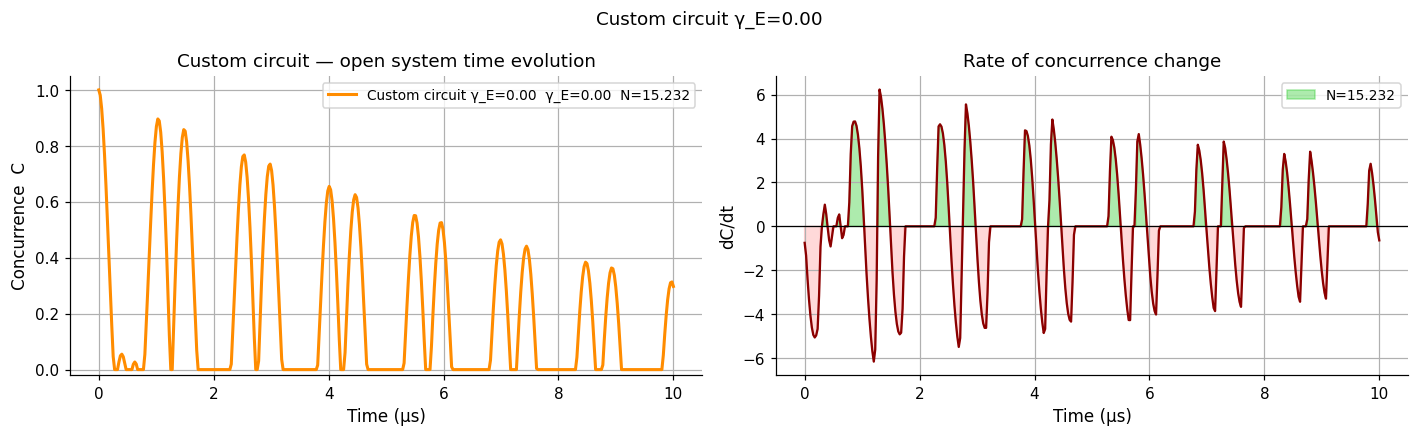

[Custom circuit γ_E=0.00]  N = 15.2323
γ_E=0.0  N=15.2323
[Custom circuit γ_E=1.00]  Initial state C₀ = 1.0000
  Circuit:
0: ──X─╭IsingXY(1.57)─┤  State
1: ────╰IsingXY(1.57)─┤  State
  QST (MLE, n_shots=256): C_MLE = 0.9106


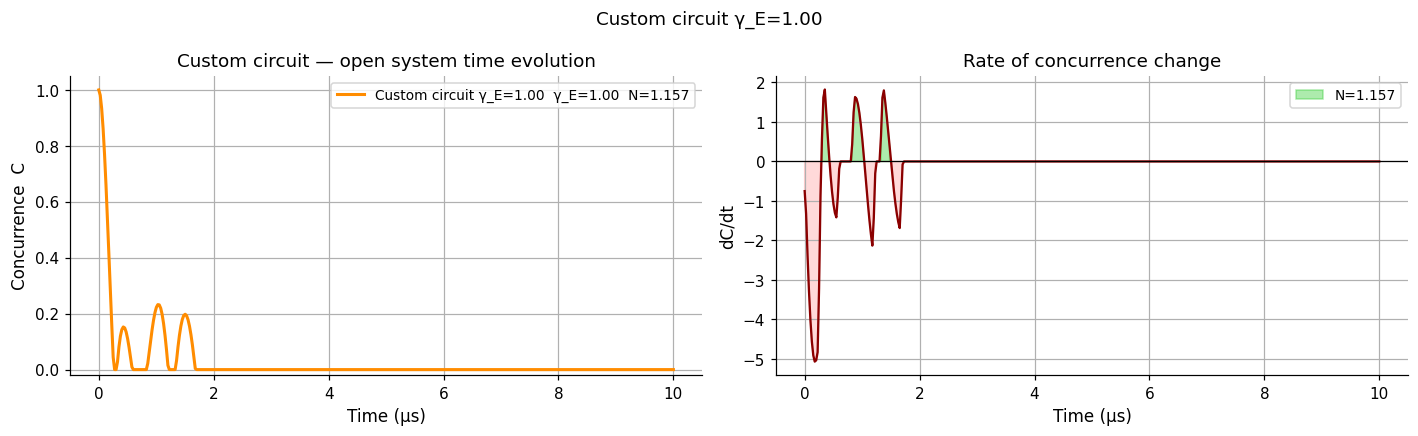

[Custom circuit γ_E=1.00]  N = 1.1570
γ_E=1.0  N=1.1570
[Custom circuit γ_E=5.00]  Initial state C₀ = 1.0000
  Circuit:
0: ──X─╭IsingXY(1.57)─┤  State
1: ────╰IsingXY(1.57)─┤  State
  QST (MLE, n_shots=256): C_MLE = 0.9106


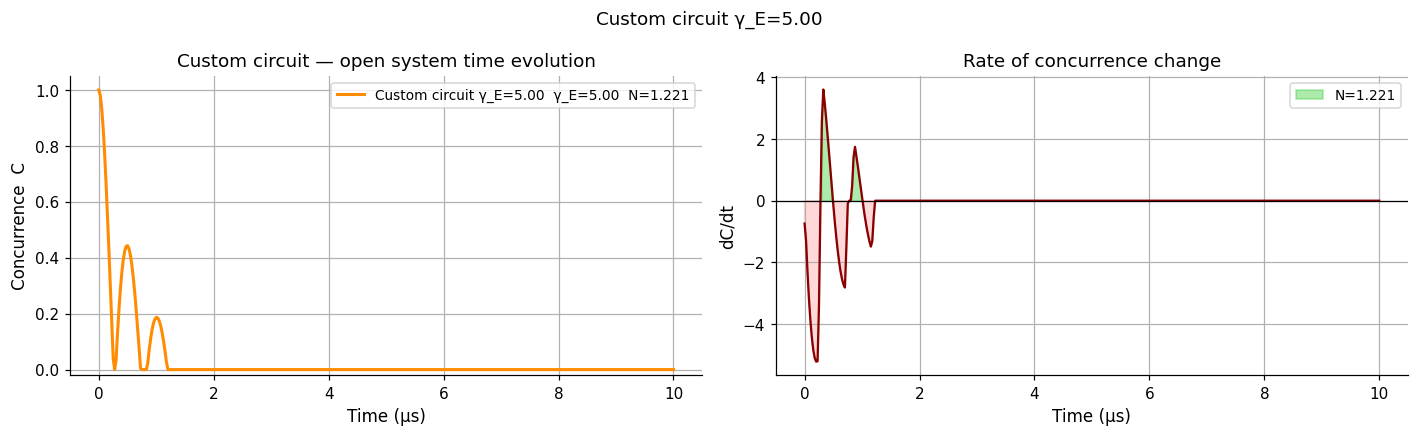

[Custom circuit γ_E=5.00]  N = 1.2211
γ_E=5.0  N=1.2211


In [ ]:
# Interactive: sweep gamma_E for the custom circuit
def run_and_plot_custom(gamma_E):
    rc = run_custom_circuit(my_circuit, gamma_E=gamma_E, params=params,
                             tlist=tlist, n_shots=256, plot=True,
                             label=f'Custom circuit γ_E={gamma_E:.2f}')
    return rc['NM']

if WIDGETS_AVAILABLE:
    interact(run_and_plot_custom,
             gamma_E=FloatSlider(min=0.0, max=15.0, step=0.5, value=0.0,
                                  description='γ_E (rad/μs)',
                                  style={'description_width': '140px'},
                                  layout=widgets.Layout(width='60%')))
else:
    for g in [0.0, 1.0, 5.0]:
        N = run_and_plot_custom(g)
        print(f'γ_E={g:.1f}  N={N:.4f}')

---
## Appendix: Wootters concurrence formula (manual implementation)

Demonstrates the Wootters formula $\mathcal{C}(\rho) = \max(0,\,\sqrt{\lambda_1}-\sqrt{\lambda_2}-\sqrt{\lambda_3}-\sqrt{\lambda_4})$
from scratch, matching QuTiP's built-in `qt.concurrence()`.

In [ ]:
from state_prep import concurrence_manual

test_cases = [
    ('|Φ+⟩ (max entangled)', qt.ket2dm(qt.bell_state('00'))),
    ('|Ψ+⟩ (max entangled)', qt.ket2dm(qt.bell_state('10'))),
    ('|00⟩  (separable)',    qt.ket2dm(qt.tensor(qt.basis(2,0), qt.basis(2,0)))),
    ('I/4   (mixed)',        qt.Qobj(np.eye(4)/4, dims=[[2,2],[2,2]])),
]

print(f'{"State":<30} {"C_manual":>10} {"C_qutip":>10} {"Match":>6}')
print('-' * 60)
for name, rho in test_cases:
    rho.dims = [[2,2],[2,2]]
    C_man, _  = concurrence_manual(rho)
    C_qt      = qt.concurrence(rho)
    match     = 'OK' if abs(C_man - C_qt) < 1e-8 else 'FAIL'
    print(f'{name:<30} {C_man:>10.6f} {C_qt:>10.6f} {match:>6}')

# Concurrence along the Exp.2 trajectory: manual vs qutip
C_manual_traj = [concurrence_manual(s.ptrace([0,1]))[0] for s in states2[:50]]
C_qutip_traj  = [qt.concurrence(s.ptrace([0,1]))       for s in states2[:50]]
max_err = max(abs(np.array(C_manual_traj) - np.array(C_qutip_traj)))
print(f'\nMax concurrence discrepancy along trajectory: {max_err:.2e}')

State                            C_manual    C_qutip  Match
------------------------------------------------------------
|Φ+⟩ (max entangled)             1.000000   1.000000     OK
|Ψ+⟩ (max entangled)             1.000000   1.000000     OK
|00⟩  (separable)                0.000000   0.000000     OK
I/4   (mixed)                    0.000000   0.000000     OK

Max concurrence discrepancy along trajectory: 6.11e-15
